# EDA 03 — Topología Cíclica: Espacio de Fases

Diagrama de dispersión conectando **Rentabilidad (X)** e **Inversión (Y)** a lo largo del tiempo.

Si la dinámica sigue la estructura de Lotka-Volterra, los puntos deben trazar **órbitas** o **espirales** en sentido antihorario.

Se comparan dos versiones:
- **YoY crudo**: variación interanual en porcentaje
- **Z-Score**: estandarizado (media=0, std=1) — elimina la diferencia de escala entre variables y es el input correcto para el optimizador de ecuaciones diferenciales

In [1]:
# ── FLAGS ──────────────────────────────────────────────
SAVE_FIGS = True
# ───────────────────────────────────────────────────────

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

DATA_DIR = Path('../data/raw')
OUT_DIR = Path('../output/notebooks')
if SAVE_FIGS:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

## Carga y Preprocesamiento

In [3]:
df = pd.read_csv(DATA_DIR / 'lotka_volterra.csv', index_col=0, parse_dates=True)

# YoY % change (elimina tendencia de largo plazo)
df['P'] = df['PROFITS'].pct_change(4) * 100
df['I'] = df['INVESTMENT'].pct_change(4) * 100
df = df.dropna()

# Z-Score sobre la tasa de crecimiento (media=0, std=1)
df['P_z'] = (df['P'] - df['P'].mean()) / df['P'].std()
df['I_z'] = (df['I'] - df['I'].mean()) / df['I'].std()

print(f"Período: {df.index[0].date()} → {df.index[-1].date()} | N={len(df)}")
print(f"\nEstadísticos Z-Score (deben ser ~0 media, ~1 std):")
print(df[['P_z', 'I_z']].describe().round(3))

Período: 1948-03-31 → 2026-03-31 | N=313

Estadísticos Z-Score (deben ser ~0 media, ~1 std):
           P_z      I_z
count  313.000  313.000
mean     0.000   -0.000
std      1.000    1.000
min     -3.404   -2.796
25%     -0.640   -0.489
50%     -0.077   -0.036
75%      0.501    0.461
max      4.770    5.967


## Comparación: YoY Crudo vs Z-Score

El YoY crudo produce una elipse aplastada porque ganancias tienen mayor volatilidad que inversión.
El Z-Score simetriza el ciclo y lo centra en el origen.

/var/folders/v5/b4dm3r7n7f309z3_jz9rkcp80000gn/T/ipykernel_33563/3573312503.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlBu_r')
/var/folders/v5/b4dm3r7n7f309z3_jz9rkcp80000gn/T/ipykernel_33563/3573312503.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/v5/b4dm3r7n7f309z3_jz9rkcp80000gn/T/ipykernel_33563/3573312503.py:40: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Times New Roman.
  plt.tight_layout()


/var/folders/v5/b4dm3r7n7f309z3_jz9rkcp80000gn/T/ipykernel_33563/3573312503.py:42: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Times New Roman.
  plt.savefig(OUT_DIR / '03_comparacion_yoy_vs_zscore.png', dpi=300, bbox_inches='tight')


/Users/juantollo/Documents/repos/structural-long-timeseries/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


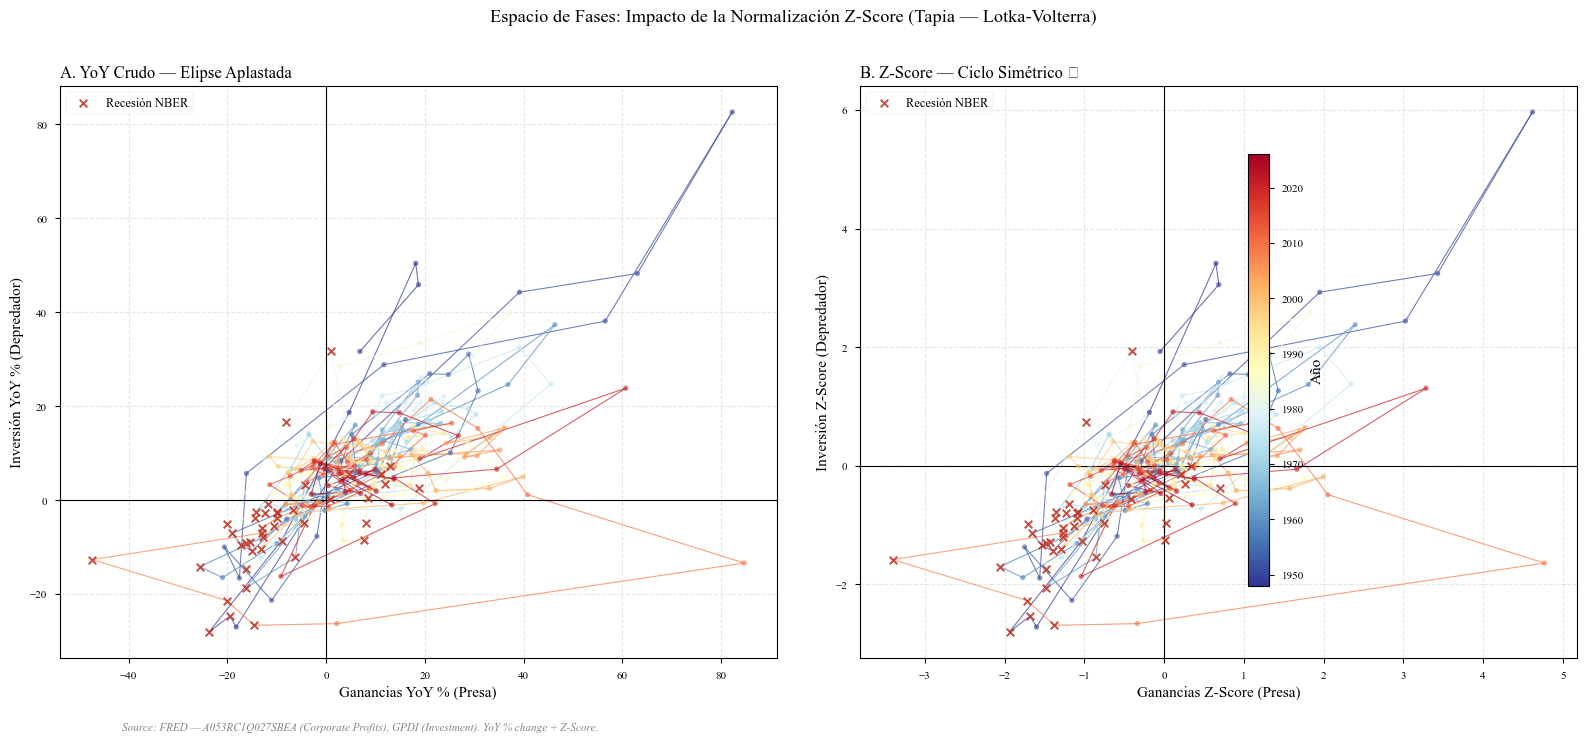

In [4]:
norm = mcolors.Normalize(vmin=df.index.year.min(), vmax=df.index.year.max())
cmap = cm.get_cmap('RdYlBu_r')
rec_mask = df['RECESSION'] > 0.5 if 'RECESSION' in df.columns else pd.Series(False, index=df.index)

def draw_phase_space(ax, x_col, y_col, xlabel, ylabel, title):
    for i in range(len(df) - 1):
        color = cmap(norm(df.index.year[i]))
        ax.plot([df[x_col].iloc[i], df[x_col].iloc[i+1]],
                [df[y_col].iloc[i], df[y_col].iloc[i+1]],
                color=color, lw=0.8, alpha=0.7)
    ax.scatter(df.loc[~rec_mask, x_col], df.loc[~rec_mask, y_col],
               c=df.index[~rec_mask].year, cmap='RdYlBu_r', vmin=norm.vmin, vmax=norm.vmax,
               s=12, alpha=0.6, zorder=3)
    ax.scatter(df.loc[rec_mask, x_col], df.loc[rec_mask, y_col],
               color='#c0392b', s=30, marker='x', alpha=0.9, zorder=4, label='Recesión NBER')
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left')
    ax.legend(fontsize=9)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
draw_phase_space(ax1, 'P', 'I',
    xlabel='Ganancias YoY % (Presa)',
    ylabel='Inversión YoY % (Depredador)',
    title='A. YoY Crudo — Elipse Aplastada')
draw_phase_space(ax2, 'P_z', 'I_z',
    xlabel='Ganancias Z-Score (Presa)',
    ylabel='Inversión Z-Score (Depredador)',
    title='B. Z-Score — Ciclo Simétrico ✓')

sm = cm.ScalarMappable(cmap='RdYlBu_r', norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=[ax1, ax2], label='Año', shrink=0.8)
fig.suptitle('Espacio de Fases: Impacto de la Normalización Z-Score (Tapia — Lotka-Volterra)', y=1.01)
fig.text(0.08, -0.02,
         'Source: FRED — A053RC1Q027SBEA (Corporate Profits), GPDI (Investment). YoY % change + Z-Score.',
         fontsize=8, color='gray', style='italic')
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(OUT_DIR / '03_comparacion_yoy_vs_zscore.png', dpi=300, bbox_inches='tight')
plt.show()

## Espacio de Fases Z-Score — Órbita completa

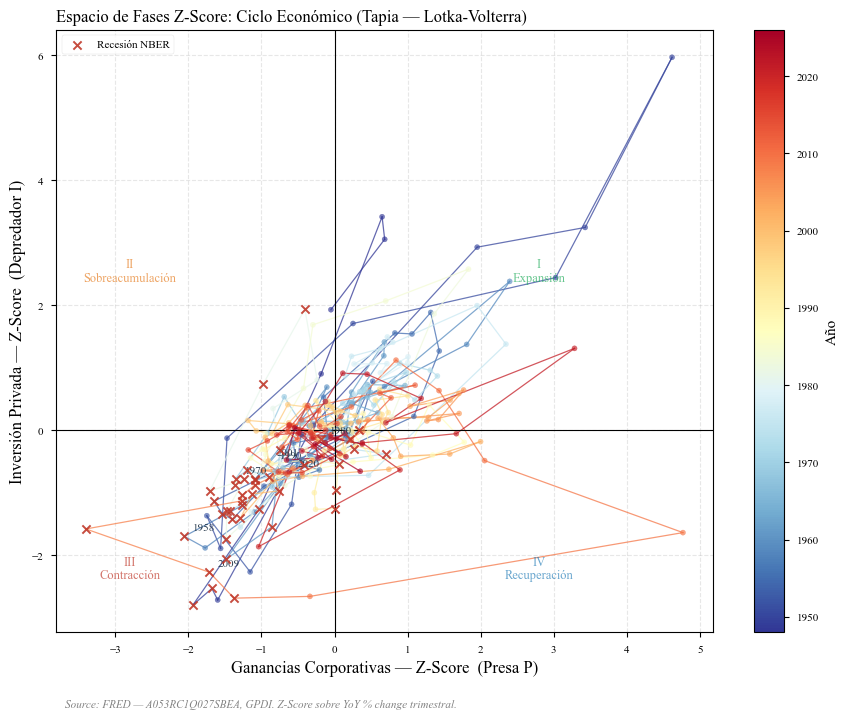

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))

for i in range(len(df) - 1):
    color = cmap(norm(df.index.year[i]))
    ax.plot([df['P_z'].iloc[i], df['P_z'].iloc[i+1]],
            [df['I_z'].iloc[i], df['I_z'].iloc[i+1]],
            color=color, lw=0.9, alpha=0.75)

ax.scatter(df.loc[~rec_mask, 'P_z'], df.loc[~rec_mask, 'I_z'],
           c=df.index[~rec_mask].year, cmap='RdYlBu_r', vmin=norm.vmin, vmax=norm.vmax,
           s=14, alpha=0.65, zorder=3)
ax.scatter(df.loc[rec_mask, 'P_z'], df.loc[rec_mask, 'I_z'],
           color='#c0392b', s=35, marker='x', alpha=0.9, zorder=4, label='Recesión NBER')

ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)

for year in [1958, 1970, 1980, 1990, 2001, 2009, 2020]:
    yr_data = df[df.index.year == year]
    if not yr_data.empty:
        ax.annotate(str(year), xy=(yr_data['P_z'].iloc[0], yr_data['I_z'].iloc[0]),
                    fontsize=8, color='#2c3e50', xytext=(6, 4), textcoords='offset points')

lim = 2.8
ax.text( lim,  lim * 0.85, 'I\nExpansión', ha='center', fontsize=9, color='#27ae60', alpha=0.7)
ax.text(-lim,  lim * 0.85, 'II\nSobreacumulación', ha='center', fontsize=9, color='#e67e22', alpha=0.7)
ax.text(-lim, -lim * 0.85, 'III\nContracción', ha='center', fontsize=9, color='#c0392b', alpha=0.7)
ax.text( lim, -lim * 0.85, 'IV\nRecuperación', ha='center', fontsize=9, color='#2980b9', alpha=0.7)

sm = cm.ScalarMappable(cmap='RdYlBu_r', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Año')
ax.set_xlabel('Ganancias Corporativas — Z-Score  (Presa P)', fontsize=12)
ax.set_ylabel('Inversión Privada — Z-Score  (Depredador I)', fontsize=12)
ax.set_title('Espacio de Fases Z-Score: Ciclo Económico (Tapia — Lotka-Volterra)', loc='left')
ax.legend(loc='upper left')
fig.text(0.08, -0.02,
         'Source: FRED — A053RC1Q027SBEA, GPDI. Z-Score sobre YoY % change trimestral.',
         fontsize=8, color='gray', style='italic')
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(OUT_DIR / '03_espacio_fases_zscore.png', dpi=300, bbox_inches='tight')
plt.show()

## Órbitas por Ciclo (Z-Score)

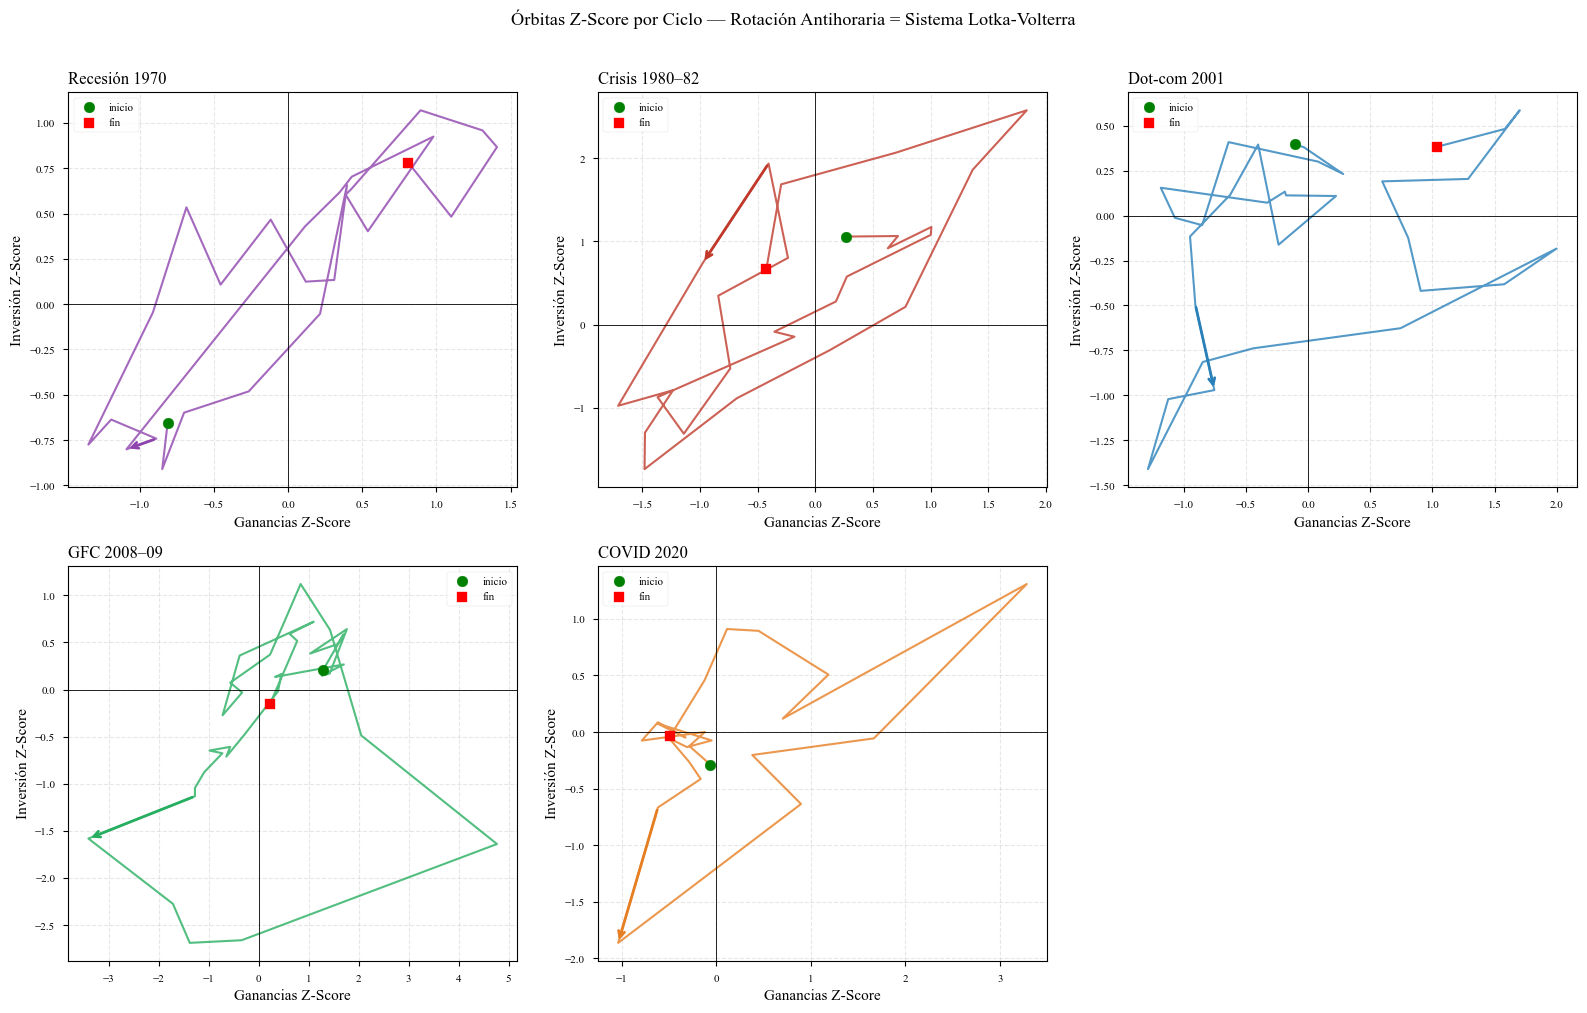

In [6]:
cycles = {
    'Recesión 1970': ('1967', '1973'),
    'Crisis 1980–82': ('1978', '1984'),
    'Dot-com 2001': ('1997', '2004'),
    'GFC 2008–09': ('2004', '2012'),
    'COVID 2020': ('2017', '2022'),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
cycle_colors = ['#8e44ad', '#c0392b', '#2980b9', '#27ae60', '#e67e22']

for ax, (label, (start, end)), color in zip(axes, cycles.items(), cycle_colors):
    sub = df.loc[start:end]
    if sub.empty or len(sub) < 3:
        ax.set_visible(False)
        continue
    ax.plot(sub['P_z'], sub['I_z'], color=color, lw=1.5, alpha=0.8)
    mid = len(sub) // 2
    ax.annotate('', xy=(sub['P_z'].iloc[mid+1], sub['I_z'].iloc[mid+1]),
                xytext=(sub['P_z'].iloc[mid], sub['I_z'].iloc[mid]),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.scatter(sub['P_z'].iloc[0], sub['I_z'].iloc[0], color='green', s=60, zorder=5, label='inicio')
    ax.scatter(sub['P_z'].iloc[-1], sub['I_z'].iloc[-1], color='red', s=60, marker='s', zorder=5, label='fin')
    ax.axhline(0, color='black', lw=0.6)
    ax.axvline(0, color='black', lw=0.6)
    ax.set_title(label, loc='left')
    ax.set_xlabel('Ganancias Z-Score')
    ax.set_ylabel('Inversión Z-Score')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Órbitas Z-Score por Ciclo — Rotación Antihoraria = Sistema Lotka-Volterra', y=1.01)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(OUT_DIR / '03_orbitas_zscore_por_ciclo.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Animación Interactiva: Trayectoria Acumulativa (Plotly)

Cada frame agrega un trimestre, mostrando cómo el "ovillo" se va dibujando cronológicamente.
Permite seguir la anatomía de cada crisis: Recuperación → Boom → Sobrecalentamiento → Contracción.

Guardado como HTML interactivo — ideal para propuesta de funding.

In [7]:
import plotly.graph_objects as go

da = df.reset_index()
da.columns = ['date'] + list(da.columns[1:])
da['label'] = da['date'].dt.strftime('%Y-Q') + da['date'].dt.quarter.astype(str)
da['phase'] = da['RECESSION'].apply(lambda x: 'Recesión' if x > 0.5 else 'Expansión')

AXIS_RANGE = [-4.2, 4.2]
START = 8  # primer frame con al menos 8 trimestres

frames = []
for i in range(START, len(da)):
    sub = da.iloc[:i+1]
    exp = sub[sub['phase'] == 'Expansión']
    rec = sub[sub['phase'] == 'Recesión']
    cur = sub.iloc[-1]

    frames.append(go.Frame(
        name=cur['label'],
        data=[
            # Trail
            go.Scatter(
                x=sub['P_z'], y=sub['I_z'], mode='lines',
                line=dict(color='rgba(150,150,180,0.35)', width=1.2),
                showlegend=False, hoverinfo='skip'
            ),
            # Expansion points
            go.Scatter(
                x=exp['P_z'], y=exp['I_z'], mode='markers',
                marker=dict(color='#2980b9', size=5, opacity=0.6),
                name='Expansión',
                text=exp['label'], hovertemplate='%{text}<br>P_z=%{x:.2f} I_z=%{y:.2f}'
            ),
            # Recession points
            go.Scatter(
                x=rec['P_z'], y=rec['I_z'], mode='markers',
                marker=dict(color='#c0392b', size=7, symbol='x', opacity=0.8),
                name='Recesión NBER',
                text=rec['label'], hovertemplate='%{text}<br>P_z=%{x:.2f} I_z=%{y:.2f}'
            ),
            # Current point
            go.Scatter(
                x=[cur['P_z']], y=[cur['I_z']], mode='markers+text',
                marker=dict(color='black', size=13, symbol='circle',
                            line=dict(color='white', width=2)),
                text=[cur['label']], textposition='top center',
                textfont=dict(size=11, color='black'),
                showlegend=False, hoverinfo='skip'
            ),
        ]
    ))

# Initial state (first frame)
f0 = frames[0]

fig = go.Figure(
    data=f0.data,
    frames=frames,
    layout=go.Layout(
        title=dict(
            text='Espacio de Fases Dinámico — Ciclo Económico Lotka-Volterra (Tapia)<br>'
                 '<sup>Ganancias Corporativas (Presa) vs Inversión Privada (Depredador) — Z-Score YoY %</sup>',
            x=0.5
        ),
        xaxis=dict(title='Ganancias Corporativas — Z-Score (Presa P)',
                   range=AXIS_RANGE, zeroline=True, zerolinecolor='black', zerolinewidth=1),
        yaxis=dict(title='Inversión Privada — Z-Score (Depredador I)',
                   range=AXIS_RANGE, zeroline=True, zerolinecolor='black', zerolinewidth=1),
        width=820, height=720,
        plot_bgcolor='white',
        paper_bgcolor='white',
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)'),
        # Quadrant labels
        annotations=[
            dict(x=3.2,  y=3.4,  text='I — Expansión',         showarrow=False, font=dict(color='#27ae60', size=11)),
            dict(x=-3.2, y=3.4,  text='II — Sobreacumulación', showarrow=False, font=dict(color='#e67e22', size=11)),
            dict(x=-3.2, y=-3.4, text='III — Contracción',     showarrow=False, font=dict(color='#c0392b', size=11)),
            dict(x=3.2,  y=-3.4, text='IV — Recuperación',     showarrow=False, font=dict(color='#2980b9', size=11)),
        ],
        updatemenus=[dict(
            type='buttons', showactive=False,
            x=0.05, y=-0.08, xanchor='left',
            buttons=[
                dict(label='▶ Play', method='animate',
                     args=[None, {'frame': {'duration': 80, 'redraw': True},
                                  'fromcurrent': True, 'transition': {'duration': 0}}]),
                dict(label='⏸ Pause', method='animate',
                     args=[[None], {'frame': {'duration': 0}, 'mode': 'immediate'}]),
            ]
        )],
        sliders=[dict(
            currentvalue=dict(prefix='Trimestre: ', font=dict(size=12)),
            pad=dict(t=50),
            steps=[dict(method='animate',
                        args=[[f.name], {'frame': {'duration': 0}, 'mode': 'immediate'}],
                        label=f.name if idx % 8 == 0 else '')
                   for idx, f in enumerate(frames)]
        )]
    )
)

fig.show()

if SAVE_FIGS:
    fig.write_html(str(OUT_DIR / '03_animacion_espacio_fases.html'))
    print(f'Saved: {OUT_DIR}/03_animacion_espacio_fases.html')

Saved: ../output/notebooks/03_animacion_espacio_fases.html


## Interpretación

| Cuadrante | P_z | I_z | Fase |
|-----------|-----|-----|------|
| I  | + | + | Expansión: ganancias altas arrastran inversión |
| II | − | + | Sobreacumulación: inversión sigue pero ganancias ya caen |
| III| − | − | Contracción: colapso sincronizado |
| IV | + | − | Recuperación: ganancias se adelantan a la inversión |

Las columnas `P_z` e `I_z` son el **input directo** para calibrar el sistema:
$$\frac{dP}{dt} = \alpha P - \beta P I \qquad \frac{dI}{dt} = \delta P I - \gamma I$$
con `scipy.optimize.minimize` minimizando el error entre la órbita teórica y los datos estandarizados.